# TP1. Analysing and visualising data with `numpy`, `pandas` and `matplotlib`

## 1. AirBnB

### 1.0 A simple scatter plot

Plot the number of reviews per month as a function of price using [`scatter`](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.plot.scatter.html?highlight=scatter#pandas.DataFrame.plot.scatter) from `pandas`.

* Plot the `reviews_per_month` as a function of `price`, what do you observe? 
* How would you plot your data if you need to answer the question "For which price does one have the maximum number of reviews per month?"

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
#convert the file into a DataFrame
df = pd.read_csv('listings.csv')
#print some infos on the dataframe as the name of the columns
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10934 entries, 0 to 10933
Data columns (total 18 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              10934 non-null  int64  
 1   name                            10931 non-null  object 
 2   host_id                         10934 non-null  int64  
 3   host_name                       10932 non-null  object 
 4   neighbourhood_group             0 non-null      float64
 5   neighbourhood                   10934 non-null  object 
 6   latitude                        10934 non-null  float64
 7   longitude                       10934 non-null  float64
 8   room_type                       10934 non-null  object 
 9   price                           10934 non-null  int64  
 10  minimum_nights                  10934 non-null  int64  
 11  number_of_reviews               10934 non-null  int64  
 12  last_review                     

Text(0, 0.5, 'Number of reviews per month')

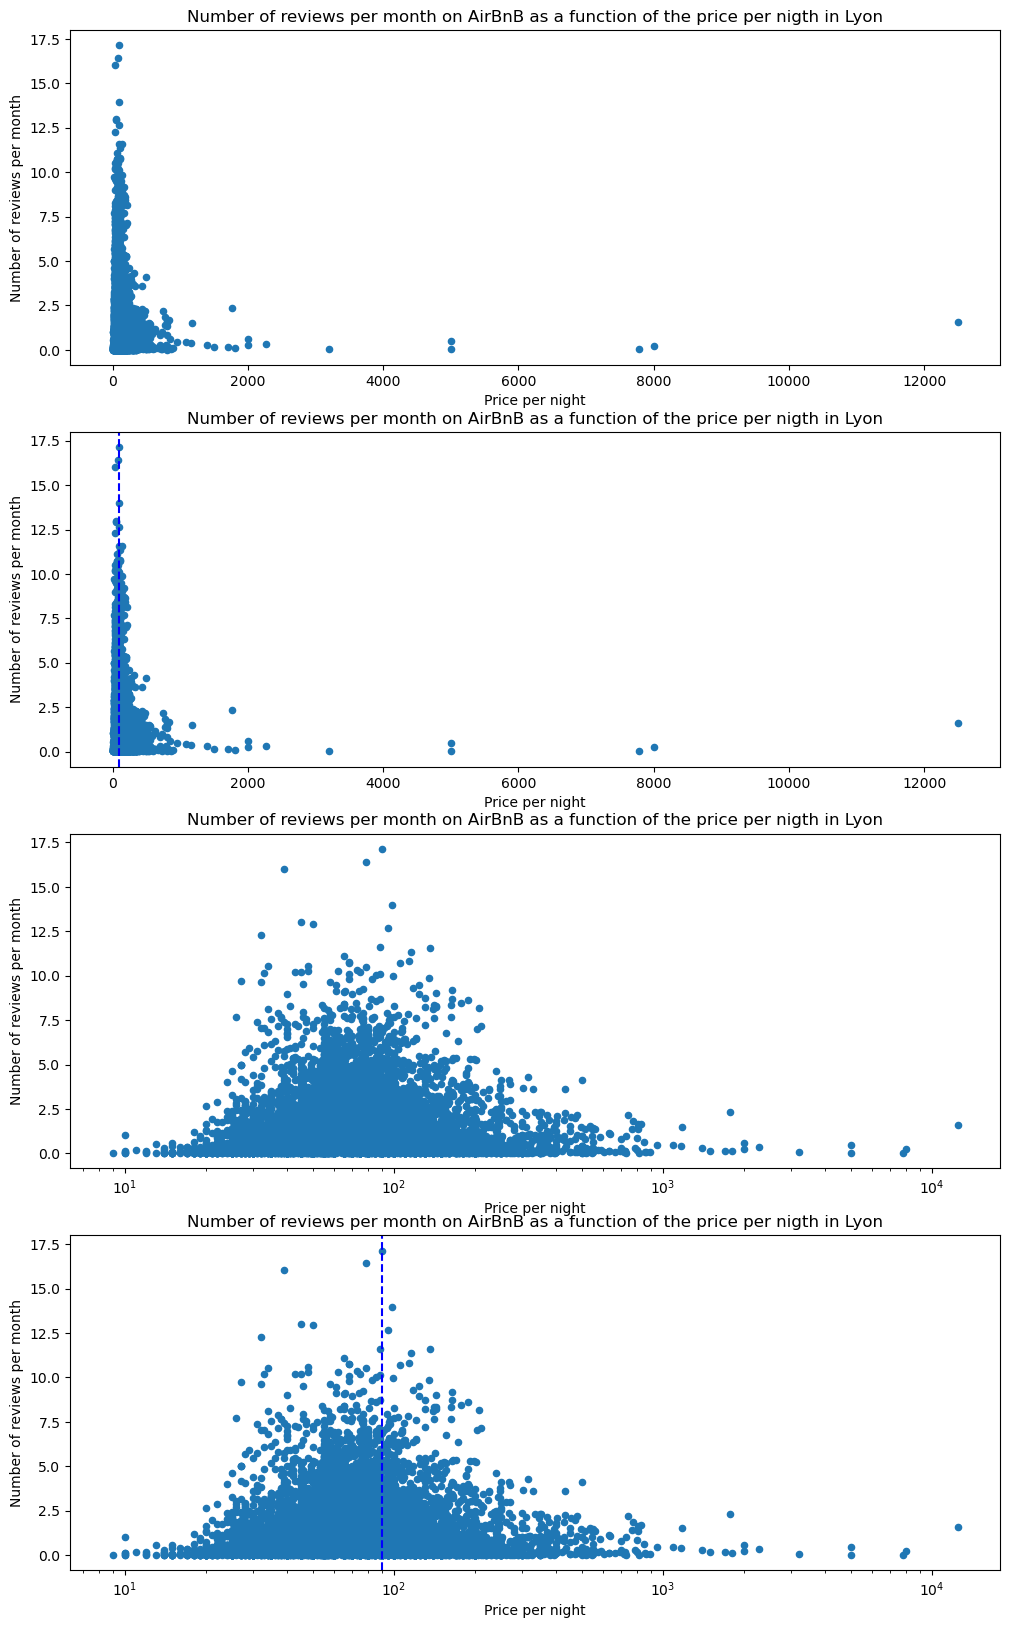

In [3]:
#Create a figure with several frames to show different plots of data in one figure
fig10, ax10 = plt.subplots(4,1, figsize=(12,20))

#Create a scatter plot of showing reviews per month as a function of price, add a title to the plot and give a position on the subplots
df.plot.scatter(x='price',y='reviews_per_month', title='Number of reviews per month on AirBnB as a function of the price per nigth in Lyon', ax=ax10[0])
#Add labels
ax10[0].set_xlabel('Price per night')
ax10[0].set_ylabel('Number of reviews per month')

#Create the same scatter plot
df.plot(kind='scatter',x='price',y='reviews_per_month', title='Number of reviews per month on AirBnB as a function of the price per nigth in Lyon', ax=ax10[1])
#Add a vertical line at the price who have the most reviews per month
ax10[1].axvline(x=df['price'].loc[df['reviews_per_month'].idxmax()], color='b', linestyle='--')
#Add labels
ax10[1].set_xlabel('Price per night')
ax10[1].set_ylabel('Number of reviews per month')


#Create the same scatter plot but this time with a logarithmic x-axis
df.plot(kind='scatter',x='price',y='reviews_per_month', title='Number of reviews per month on AirBnB as a function of the price per nigth in Lyon', ax=ax10[2],logx=True)
#Add labels
ax10[2].set_xlabel('Price per night')
ax10[2].set_ylabel('Number of reviews per month')

#Same scatter plot as previous
df.plot(kind='scatter',x='price',y='reviews_per_month', title='Number of reviews per month on AirBnB as a function of the price per nigth in Lyon', ax=ax10[3], logx=True)
#Add a vertical line at the price who have the most reviews per month
ax10[3].axvline(x=df['price'].loc[df['reviews_per_month'].idxmax()], color='b', linestyle='--')
#Add labels
ax10[3].set_xlabel('Price per night')
ax10[3].set_ylabel('Number of reviews per month')

#### Is a linear scale on the price convenient? How to change to a logarithmic scaling?

* No, it’s not, because prices have a wide range of values. As a result, most of the points are concentrated on the left side of the plot, making the data difficult to visualize. By using a logarithmic scale, we correct this issue. The pandas.DataFrame.plot() method has a boolean parameter called "logx". Its default value is False, and by setting it to True, we switch to a logarithmic scale.

---

### 1.1 A scatter plot for spatial data 

The goal is now to visualise the price per night as a function of the geospatial location (longitude, latitude); no need to project data, you may assume the earth locally flat. The data should be presented using a [scatter plot](https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.scatter.html) where

* the size of the dot `s` is proportional to the price per night
* the color of the dot `c` is _proportional_ to the occupation (proportional in days/year), choosing a greyscale for the color map (black is most occupied, white is less occupied).

Do not forget to put a colorbar next to your plot, helping the observer in its interpretation.

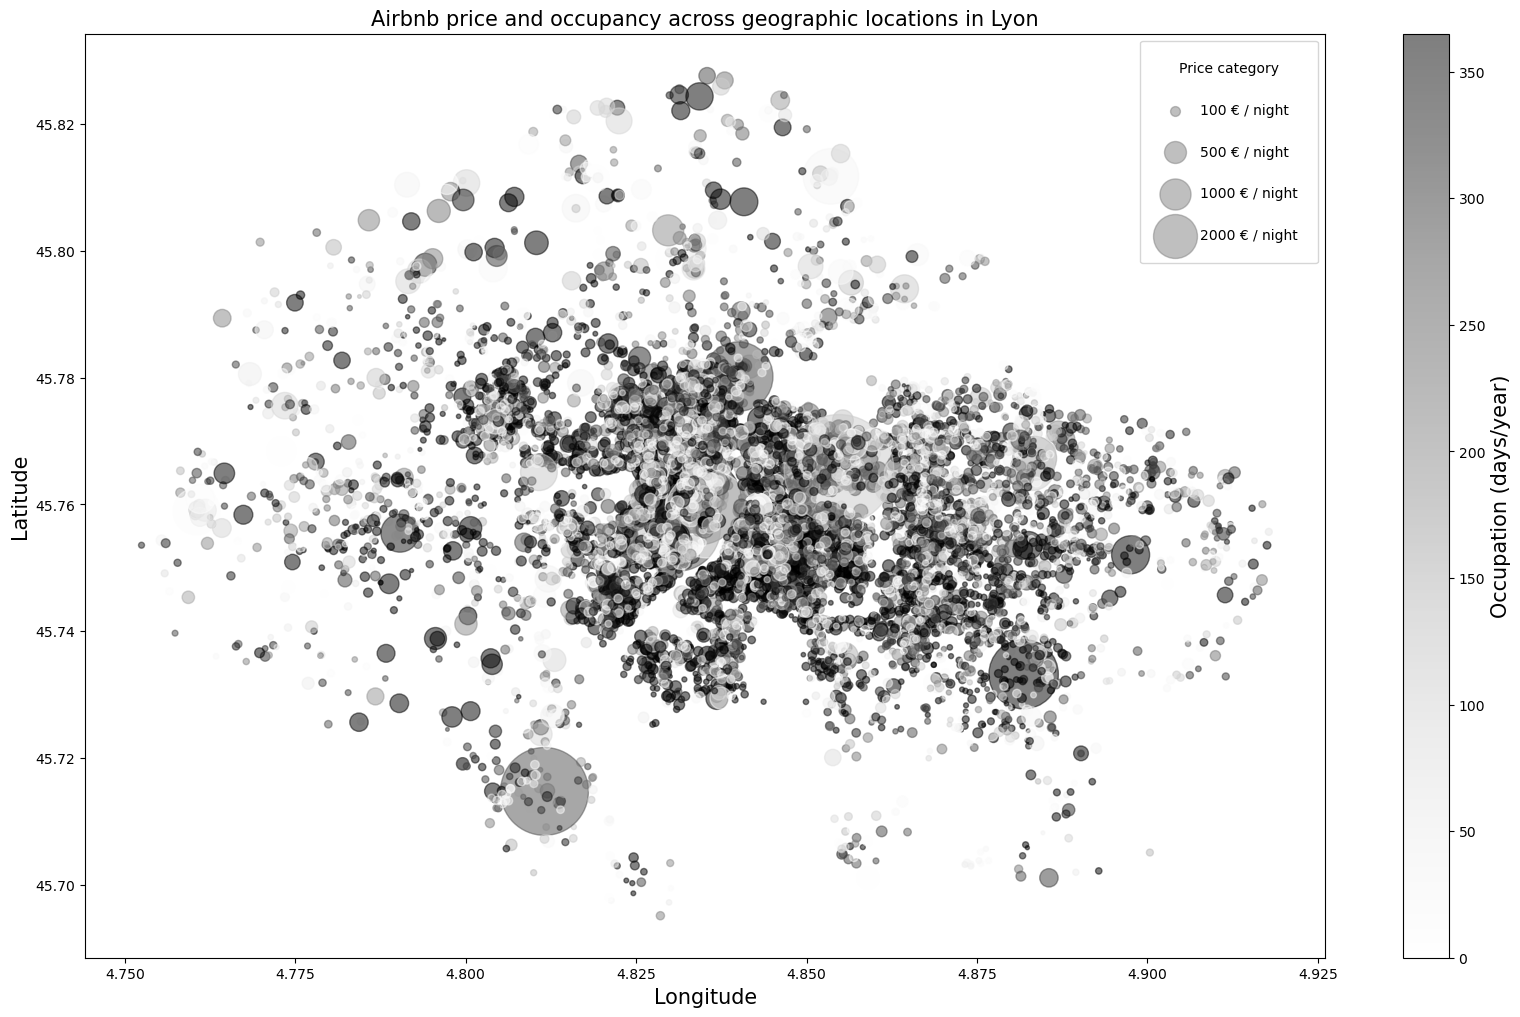

In [4]:
#Create a figure to set the size of the frame where the plot will be shown
fig11, ax11= plt.subplots(figsize=(20,12))

#Set the x-axis
x = df['longitude']
#Set the y-axis
y = df['latitude']
#Size of the dot proportionnal to the price
#We divide by two to have a better visualization
size=df['price']/2
#Colors of the dot proportionnal to the occupation in days/year
colors=df['availability_365']
#Create a scatter plot of showing Airbnb price and occupancy across geographic locations in Lyon
sc=ax11.scatter(x, y, s=size, c=365-colors, alpha=0.5, cmap='Greys')

#Add colorbar for occupancy
cb=fig11.colorbar(sc)
#Set a label and a fontsize of the label to the colorbar
cb.set_label(label='Occupation (days/year)', fontsize=15)


#Create legend for some size of dots, credit to ChatGPT for the idea
ax11.scatter([], [], s=100/2, color='gray', alpha=0.5,label=f'100 € / night')
ax11.scatter([], [], s=500/2, color='gray', alpha=0.5,label=f'500 € / night')
ax11.scatter([], [], s=1000/2, color='gray', alpha=0.5,label=f'1000 € / night')
ax11.scatter([], [], s=2000/2, color='gray', alpha=0.5,label=f'2000 € / night')
# Create a legend for the price category, borderpard set the size of the box, labelspacing the space between label in the box
ax11.legend(title='Price category', loc='upper right', borderpad=1.5, labelspacing=2)

#Add a title to the plot
ax11.set_title('Airbnb price and occupancy across geographic locations in Lyon',fontsize=15)
#Add labels
ax11.set_xlabel('Longitude',fontsize=15)
ax11.set_ylabel('Latitude',fontsize=15)

plt.show()

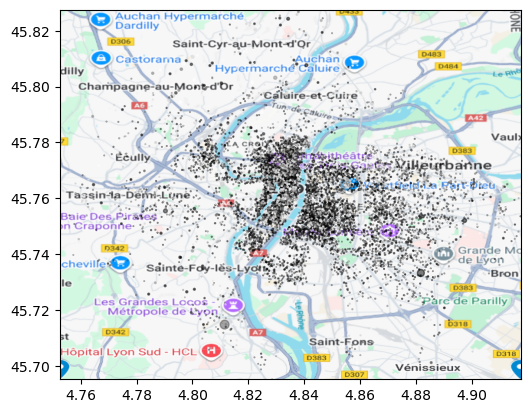

In [5]:
#We can display this plot over a map of Lyon to see the match
#It seems accurate since there is no dot on the river
#Load the image
img = plt.imread("Capture d’écran 2025-10-18 123556.png")
#display it,extent parameter is to set the bounding box in data coordinates that the image will fill.
plt.imshow(img, extent=[df['longitude'].min(), df['longitude'].max(), df['latitude'].min(), df['latitude'].max()])
#Create a scatter plot of showing Airbnb price and occupancy across geographic locations in Lyon
plt.scatter(x, y, s=size/100, c=365-colors, alpha=0.5, cmap='Greys')
plt.show()

# 2. Occupancy dataset

## 2.0 Loading data

* When loading the data into a `dataframe`, make sure to use the date as the _index_: this will allow you to conveniently call any plotting function on your data.
* The data contains multiple attributes, most of them being _features_ that help to predict the target value _occupancy_ (binary value). 

## 2.1 A simple display

Using subplots, plot all of the different features, each time using a dual y-axis. On the left-hand y-axis the feature value will be given, on the righ-hand y-axis you will have the _occupancy_.
To do so proceed in steps

1. make sure you are able to draw a single graph of any of the chosen features as a function of the date
2. plot the _occupancy_ on a secondary y-axis
3. make multiple subplots with _occupancy_ on the secondary y-axis, one for each feature

## 2.2 Pairwise interaction plot

* Use the function [`scatter_matrix`](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.plotting.scatter_matrix.html?highlight=scatter_matrix#pandas.plotting.scatter_matrix) to make a pairwise interaction plot, or [`pairplot`](https://seaborn.pydata.org/generated/seaborn.pairplot.html) from `seaborn`. The latter takes an additional `hue` keyword that makes it possible to distinguish on the level of _occupancy_.
* Once your plot is ready, write a paragraph documenting your observations from the pairwise interaction plot.


In [6]:
#Convert the file into a DataFrame
datao=pd.read_csv('datatraining.txt')
#Convert the date column as the index, inplace set to True means that we xhange directly the dataframe
datao.set_index('date', inplace=True)
#Print the head of the DataFrame
datao.head()

,Temperature,Humidity,Light,CO2,HumidityRatio,Occupancy
date,,,,,,
2015-02-04 17:51:00,23.18,27.2720,426.0,721.25,0.004793,1
2015-02-04 17:51:59,23.15,27.2675,429.5,714.00,0.004783,1
2015-02-04 17:53:00,23.15,27.2450,426.0,713.50,0.004779,1
2015-02-04 17:54:00,23.15,27.2000,426.0,708.25,0.004772,1
2015-02-04 17:55:00,23.10,27.2000,426.0,704.50,0.004757,1


Text(0.5, 1.0, 'Occupancy as a function of the date')

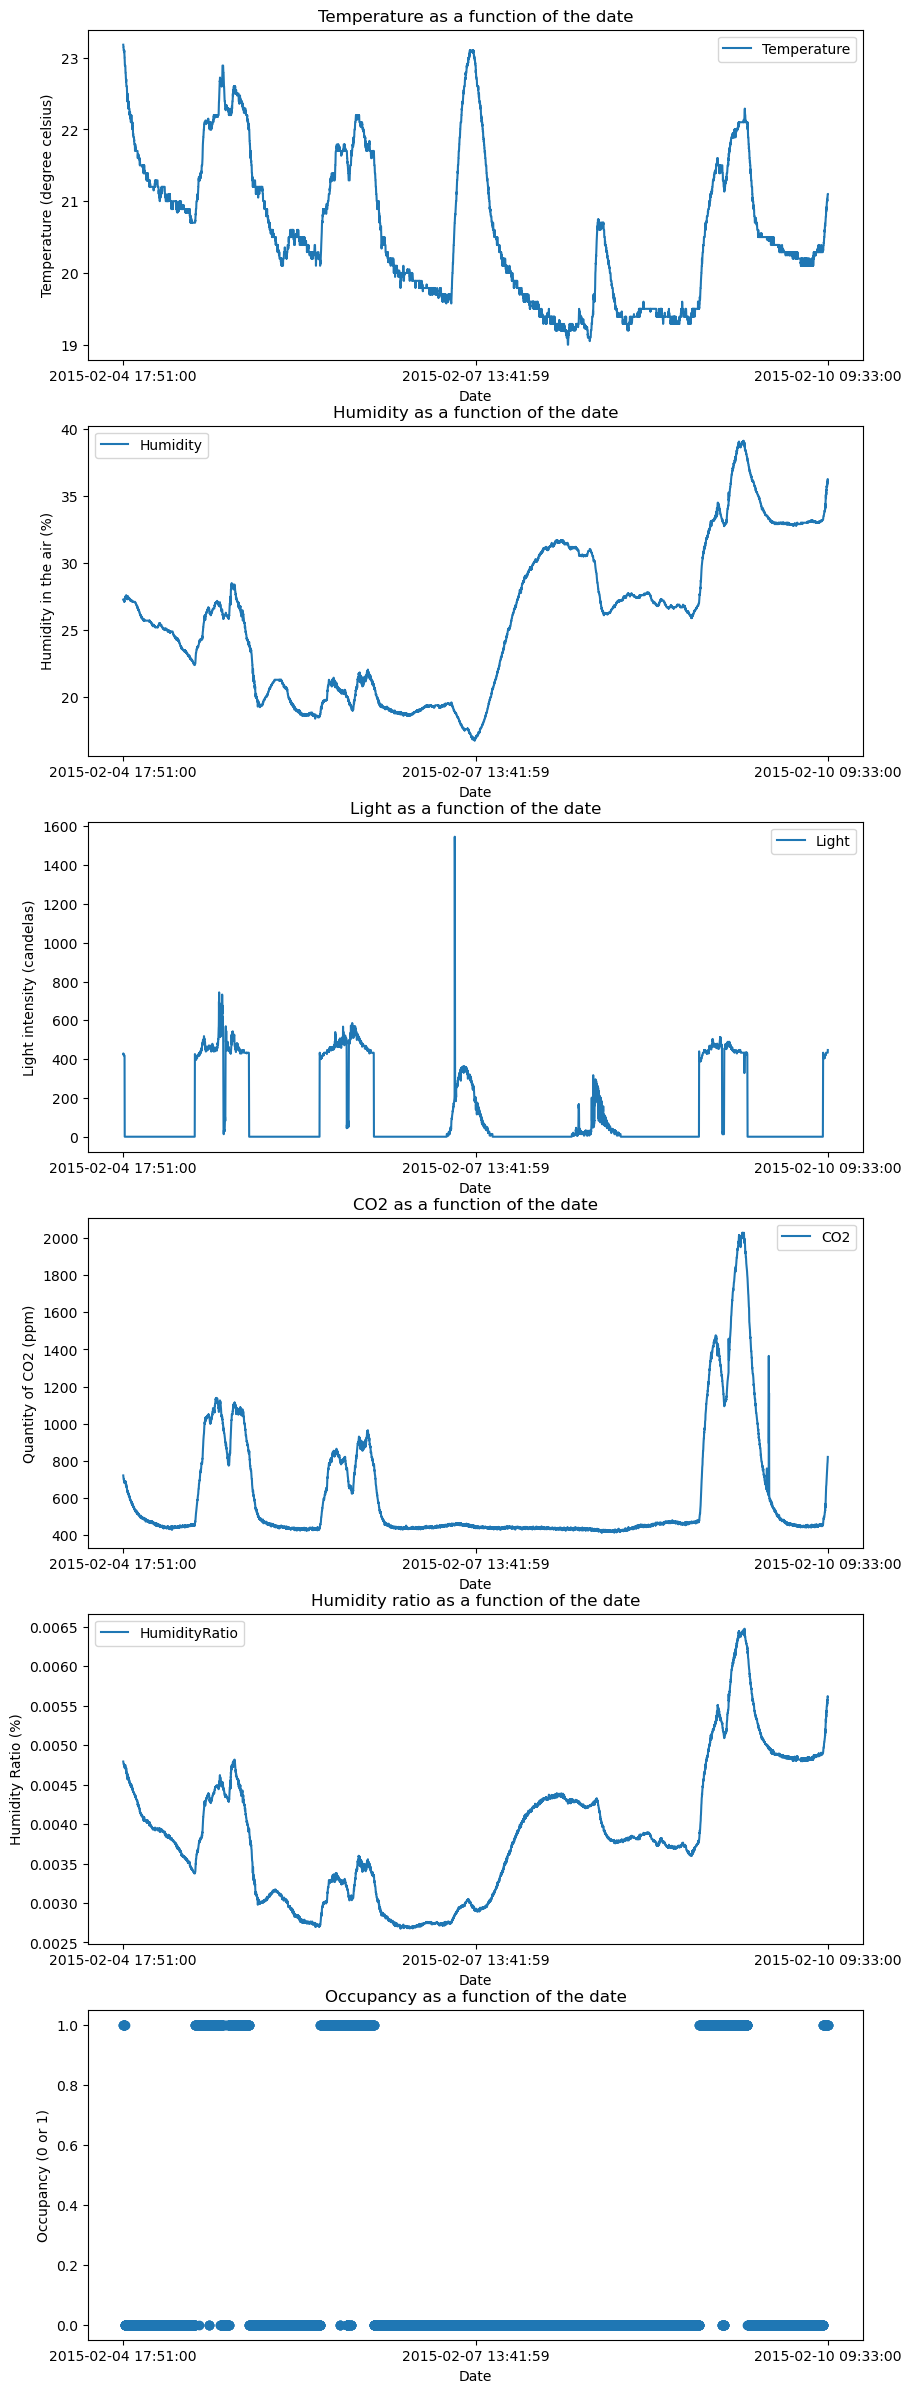

In [7]:
#Create a figure with several frames to show different plots of data in one figure
fig21_1, ax21_1 =plt.subplots(6,1, figsize=(10,30))

#Create a line plot of showing temperature in the room as a function of the date, add labels to the axis and a title to the plot, 
#gives a position on the subplots, set the ticks of the index 
datao.plot(kind='line', y='Temperature', xticks=[0,4071,8142], xlabel='Date', ylabel='Temperature (degree celsius)', 
           title='Temperature as a function of the date', ax=ax21_1[0])

#Create a line plot of showing the percentage of humidity in the air in the room as a function of the date, 
#add labels to the axis and a title to the plot, gives a position on the subplots, set the ticks of the index 
datao.plot(kind='line', y='Humidity', xticks=[0,4071,8142], xlabel='Date', ylabel='Humidity in the air (%)', 
           title='Humidity as a function of the date', ax=ax21_1[1])

#Create a line plot of showing light intensity as a function of the date, add labels to the axis and a title to the plot, 
# gives a position on the subplots, set the ticks of the index 
datao.plot(kind='line', y='Light', xticks=[0,4071,8142], xlabel='Date', ylabel='Light intensity (candelas)', 
           title='Light as a function of the date', ax=ax21_1[2])

#Create a line plot of showing the quantity of CO2 in the room as a function of the date, add labels to the axis and a title to the plot, 
#gives a position on the subplots, set the ticks of the index 
datao.plot(kind='line', y='CO2', xticks=[0,4071,8142], xlabel='Date', ylabel='Quantity of CO2 (ppm)', 
           title='CO2 as a function of the date', ax=ax21_1[3])

#Create a line plot of showing percentage of humidity ratio in the room as a function of the date, 
#add labels to the axis and a title to the plot, gives a position on the subplots, set the ticks of the index 
datao.plot(kind='line', y='HumidityRatio', xticks=[0,4071,8142], xlabel='Date', ylabel='Humidity Ratio (%)', 
           title='Humidity ratio as a function of the date', ax=ax21_1[4])

#Create a scatter plot of showing occupancy in the room as a function of the date and gives a position on the subplots
ax21_1[5].scatter(datao.index, datao['Occupancy'])
#Set the ticks of the index 
ax21_1[5].set_xticks([0, 4071, 8142])
#Add labels to the axis
ax21_1[5].set_xlabel('Date')
ax21_1[5].set_ylabel('Occupancy (0 or 1)')
#Add a title
ax21_1[5].set_title('Occupancy as a function of the date')

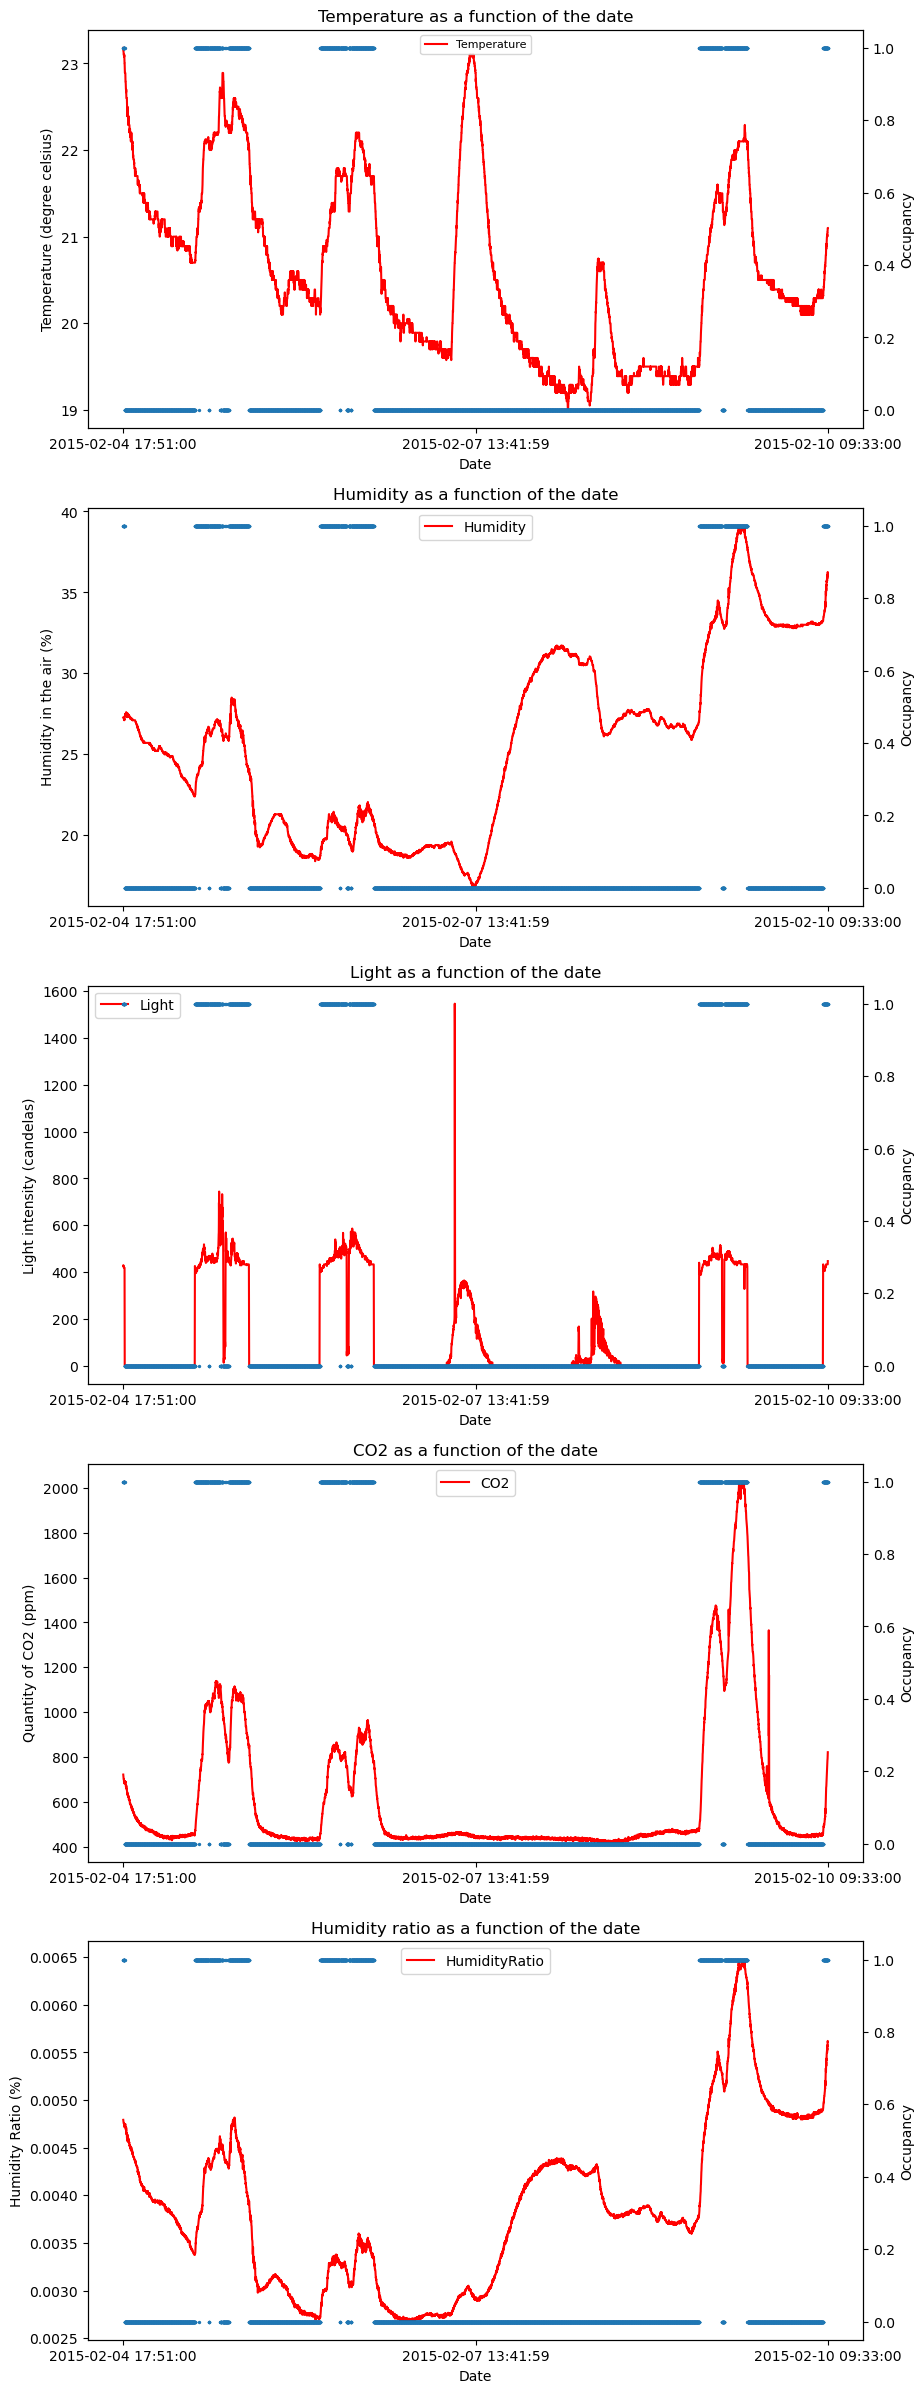

In [8]:
#Create a figure with several frames to show different plots of data in one figure
fig6, ax6 = plt.subplots(5,1,figsize=(10, 30))

#Create a line plot of showing temperature in the room as a function of the date, add labels to the axis and a title to the plot, 
#gives a position on the subplots, set the ticks of the index 
datao.plot(kind='line', 
           y='Temperature', 
           xticks=[0,4071,8142], 
           xlabel='Date', 
           ylabel='Temperature (degree celsius)', 
           title='Temperature as a function of the date', 
           ax=ax6[0], 
           color=['red'])
#Create a legend, set the position on the plot and the fontsize
ax6[0].legend(loc='upper center', 
              fontsize=8)

#Create a twin Axes sharing the xaxis, ref to https://matplotlib.org/stable/api/_as_gen/matplotlib.axes.Axes.twinx.html
secax0 = ax6[0].twinx()
#Add a label to the secundary y-axis
secax0.set_ylabel("Occupancy")
#Create a scatter plot of the occupancy as a function of the date, set the size and the color of the dot, add a label
secax0.scatter(datao.index, datao["Occupancy"], color='tab:blue', label='Occupancy', s=2)

#The following lines have the same structure of code so I will not comment them since the comments will be nearly the same

datao.plot(kind='line', 
           y='Humidity', 
           xticks=[0,4071,8142], 
           xlabel='Date', 
           ylabel='Humidity in the air (%)', 
           title='Humidity as a function of the date', 
           ax=ax6[1], 
           color=['red'])

ax6[1].legend(loc='upper center')

secax1 = ax6[1].twinx()
secax1.set_ylabel("Occupancy")
secax1.scatter(datao.index, datao["Occupancy"], color='tab:blue', label='Occupancy', s=2)

datao.plot(kind='line', 
           y='Light', 
           xticks=[0,4071,8142], 
           xlabel='Date', 
           ylabel='Light intensity (candelas)', 
           title='Light as a function of the date', 
           ax=ax6[2], 
           color=['red'])

ax6[2].legend(loc='upper left')

secax2 = ax6[2].twinx()
secax2.set_ylabel("Occupancy")
secax2.scatter(datao.index, datao["Occupancy"], color='tab:blue', label='Occupancy', s=2)



datao.plot(kind='line', 
           y='CO2', 
           xticks=[0,4071,8142], 
           xlabel='Date', 
           ylabel='Quantity of CO2 (ppm)', 
           title='CO2 as a function of the date', 
           ax=ax6[3], 
           color=['red'])

ax6[3].legend(loc='upper center')

secax3 = ax6[3].twinx()
secax3.set_ylabel("Occupancy")
secax3.scatter(datao.index, datao["Occupancy"], color='tab:blue', label='Occupancy', s=2)


datao.plot(kind='line', 
           y='HumidityRatio', 
           xticks=[0,4071,8142], 
           xlabel='Date', 
           ylabel='Humidity Ratio (%)', 
           title='Humidity ratio as a function of the date', 
           ax=ax6[4], 
           color=['red'])

ax6[4].legend(loc='upper center')

secax4 = ax6[4].twinx()
secax4.set_ylabel("Occupancy")
secax4.scatter(datao.index, datao["Occupancy"], color='tab:blue', label='Occupancy', s=2)

plt.show()

## 2.2 Pairwise interaction plot

* Use the function [`scatter_matrix`](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.plotting.scatter_matrix.html?highlight=scatter_matrix#pandas.plotting.scatter_matrix) to make a pairwise interaction plot, or [`pairplot`](https://seaborn.pydata.org/generated/seaborn.pairplot.html) from `seaborn`. The latter takes an additional `hue` keyword that makes it possible to distinguish on the level of _occupancy_.
* Once your plot is ready, write a paragraph documenting your observations from the pairwise interaction plot.

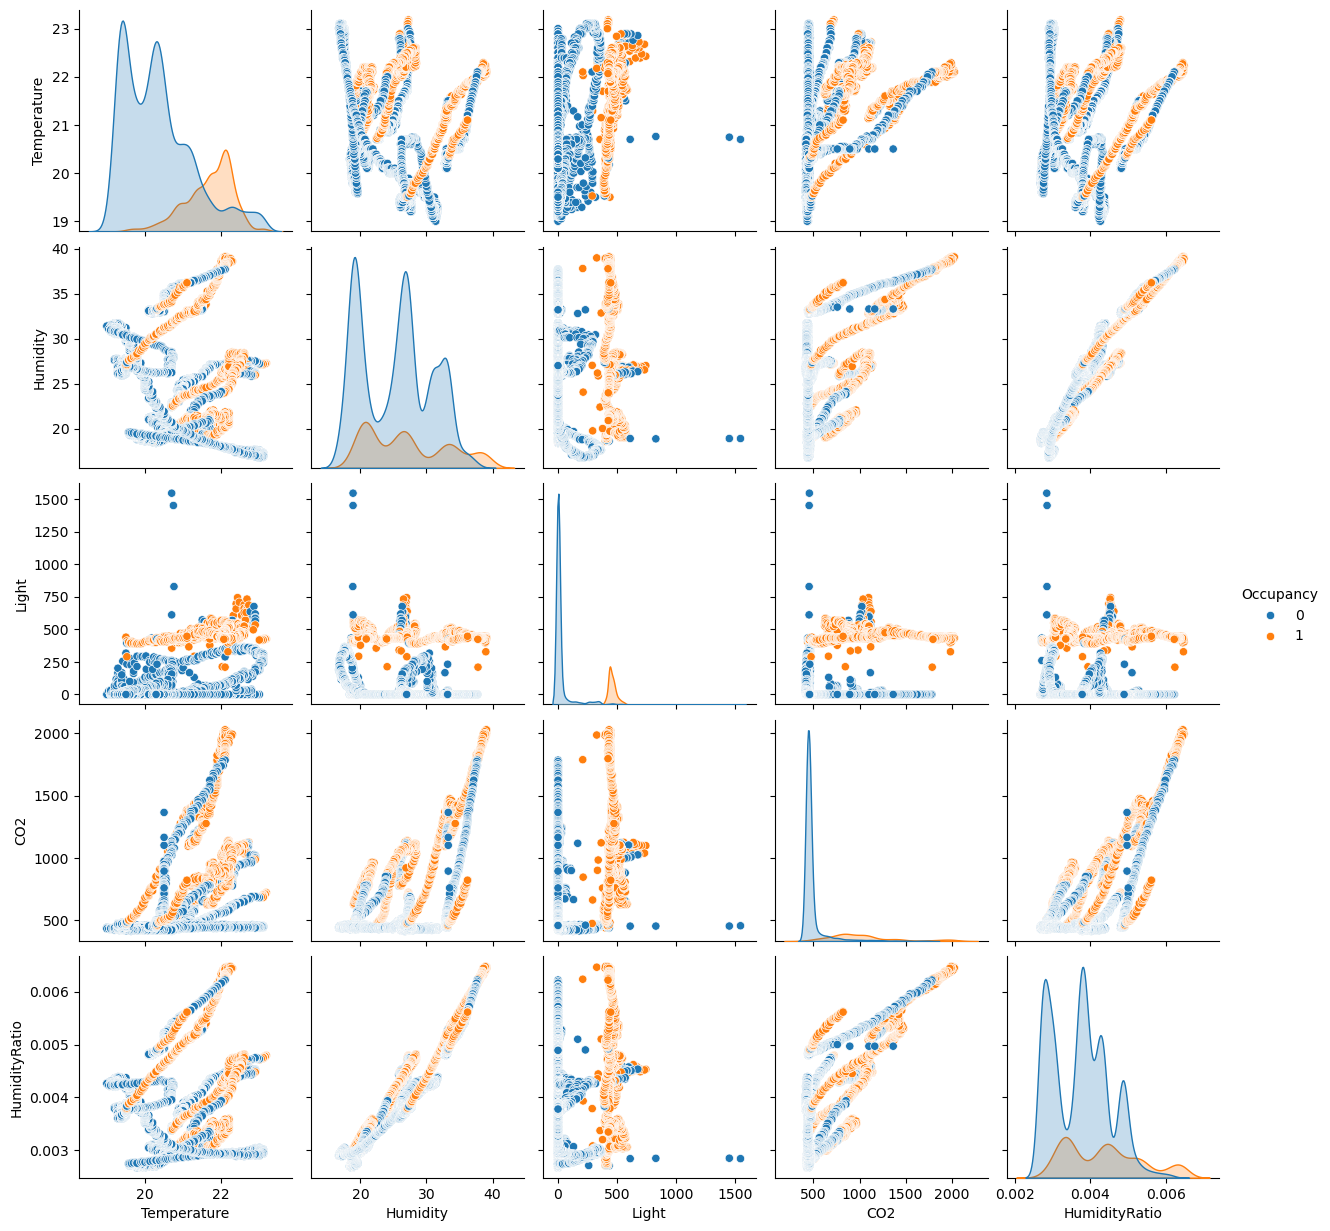

In [9]:
import seaborn

#Create a pair plot of the dataset 'datao', the hue parameter colored the points based on the 'Occupancy' column
seaborn.pairplot(datao,hue='Occupancy')

From the pairwise interaction plot, we can see that the light variable, when compared with the other parameters, consistently shows a clear distinction between zero occupancy and one occupancy. A similar pattern can be observed for temperature  when plotted against Temperature. The fact that light provides such a clear separation is likely due to the instantaneous change in light intensity in response to occupancy, whereas changes in the other parameters occur more gradually over time.

## 3. PhysioZoo

### 3.0 Objectives

The goal is to detect the heart beats of a mammal as a function of time, thereto, one needs to parse the text files to get the metadata (sampling rate, mammal, type of electrophysiological measurement, channels with units and type) and the data (sampled time-series).

Remark that a sample frequency $Fs$ denotes that each sample is distanced in time by $T_s = 1/F_s$, $n$ samples thus cover a duration of $(n-1)T_s = (n-1)/F_s$ seconds. 

### 3.1 Parsing and reading data

1. read in a data file, creating functions to parse the header for parameters. For a given file, return the channel parameters in a dataframe data, the key-value parameters in a dictionary
1. load the data in a `numpy` ndarray using [`numpy.loadtxt`](https://numpy.org/doc/stable/reference/generated/numpy.loadtxt.html) with the parameter `skiprows`.
1. Plot a channel of data over a reduced temporal window by calling a function you've created. Start time and window duration are arguments to your plotting function.

### 3.2 Peak detection

1. Run a peak detection algorithm such as [`find_peaks`](https://docs.scipy.org/doc/scipy/reference/generated/scipy.signal.find_peaks.html) from `scipy.signal` to detect the local maxima (store these in an attribute of the object), which will give you the time/beat over that interval (time between two successive local maxima), which could easily be converted to beats/time = heart rate. Visualise the detected peaks by putting a star on the coordinates (time of local maximum, amplitude of local maximum) and add them to the plot function above.
1. visualise the heart rate as a function of time (choose the mid-point of the beat-to-beat interval as the reference time for the heart-rate computed over the beat-to-beat interval). The instant heart-rate may be considered as 1/(temporal distance separating two consecutive peaks).

### Hints

* use a [context](https://docs.python.org/3/reference/compound_stmts.html#with) manager to [read](https://docs.python.org/3/tutorial/inputoutput.html#reading-and-writing-files) in a text file.
* You may want to use the [`glob`](https://docs.python.org/3/library/glob.html) module from the standard library to iterate through multiple files on a given path.

In [11]:
# Import module
import os

#Assign directory
directory = r"C:\Users\Charles\Documents\etudes\python\workspace1\scientific_programming\labwork\lab_1\physiozoo"
#Create an empty dictionnary
d={}
#Create a DataFrame and some columns
df=pd.DataFrame({'id':[], 'type':[], 'name':[], 'unit':[], 'enable':[] })
#Iterate over files in directory
for name in os.listdir(directory):
    #Check if the path is file or another directory
    if os.path.isdir(os.path.join(directory, name)) == True :
        #If yes, create a key with the name of the specie
        d[name]={}
        #Create a new directory to loop over
        subdirectory = os.path.join(directory, name)
        #Iterate over files in new directory
        for subname in os.listdir(subdirectory):
            #Check if the path is file or another directory
            if os.path.isdir(os.path.join(subdirectory, subname)) == True :
                #if yes, create a key with the name of the subject
                d[name][subname]={}
                #Create a new directory to loop over
                subsubdirectory = os.path.join(subdirectory, subname)
                #Iterate over files in new directory
                for subsubname in os.listdir(subsubdirectory):
                    #Check if "electrography" is in the name of the file to only get the electrography files
                    if "electrography" in subsubname:
                    # Open file
                        with open(os.path.join(subsubdirectory, subsubname)) as f:
                            #Counter for '---'
                            a=0
                            #Variable to know if we pass the 'channels' line
                            channel=False
                            #Create a liste to stock the channels informations
                            liste=[subname]
                            #Iterate over the lines of the file
                            for line in f:
                                #Get rid of the space in each line
                                l=line.split()
                                #Check if we are still in the header
                                if a<2:
                                    #If line is '---'
                                    if l == ['---']:
                                        #Add one to the counter of '---'
                                        a+=1
                                    #If line contains more than one item
                                    elif len(l)>1 :
                                        #Check the first item of the list 
                                        if l[0] in ['Mammal:', 'Fs:', 'Integration_level:'] :
                                            #If True, we create a key dictionnary, for l[0]=='Mammal:', l[0][0:len(l[0])-1 returns 'Mammal' without the ':'
                                            #We associate the next item in the list l to the key 
                                            d[name][subname][l[0][0:len(l[0])-1]]=l[1]
                                        #If we pass the line channel
                                        if channel==True:
                                            #Take the last item of the list and appends it to liste
                                            liste.append(l[len(l)-1])
                                    #Check if the list is "Channels:"
                                    elif l==['Channels:']:
                                        #If yes change the variable
                                        channel=True
                                #If a>2 means that we finished with the header
                                else:
                                    #Create a new DataFrame to stock the informations of 'Channeles'
                                    new_df = pd.DataFrame({'id':[liste[0]], 'type':[liste[1]], 'name':[liste[2]], 'unit':[liste[3]], 'enable':[liste[4]]})
                                    #Concat the new Dataframe with the one we create at the beginning
                                    df= pd.concat([df, new_df], ignore_index=True)
                                    #Load the date below the header, I don't need to use skiprows because there is a hidden counter when running the open file
                                    #since i run all the previous lines I am already at the line where the data begin
                                    d[name][subname]['data']=np.loadtxt(f)
                                    #Break the loop 
                                    break
print(d)
df

{'dog': {'Dog_01': {'Mammal': 'dog', 'Fs': '500', 'Integration_level': 'electrocardiogram', 'data': array([-0.006394, -0.003957, -0.001813, ..., -0.034776, -0.039961,
       -0.04425 ])}, 'Dog_02': {'Mammal': 'dog', 'Fs': '500', 'Integration_level': 'electrocardiogram', 'data': array([-0.052186, -0.056458, -0.054932, ..., -0.013123, -0.014343,
       -0.015869])}, 'Dog_03': {'Mammal': 'dog', 'Fs': '500', 'Integration_level': 'electrocardiogram', 'data': array([-0.064698, -0.054322, -0.042725, ..., -0.012512, -0.012207,
       -0.011597])}, 'Dog_04': {'Mammal': 'dog', 'Fs': '500', 'Integration_level': 'electrocardiogram', 'data': array([ 0.013428,  0.010071,  0.00763 , ..., -0.035096, -0.032959,
       -0.030518])}, 'Dog_05': {'Mammal': 'dog', 'Fs': '500', 'Integration_level': 'electrocardiogram', 'data': array([ 0.060057,  0.064323,  0.068589, ..., -0.052529, -0.051023,
       -0.047928])}, 'Dog_06': {'Mammal': 'dog', 'Fs': '500', 'Integration_level': 'electrocardiogram', 'data': array

,id,type,name,unit,enable
0,Dog_01,electrography,Data,mV,yes
1,Dog_02,electrography,Data,mV,yes
2,Dog_03,electrography,Data,mV,yes
3,Dog_04,electrography,Data,mV,yes
4,Dog_05,electrography,Data,mV,yes
5,Dog_06,electrography,Data,mV,yes
6,Dog_07,electrography,Data,mV,yes
7,Dog_08,electrography,Data,mV,yes
8,Dog_09,electrography,Data,mV,yes
9,Dog_10,electrography,Data,mV,yes


 Plot a channel of data over a reduced temporal window by calling a function you've created. Start time and window duration are arguments to your plotting function.


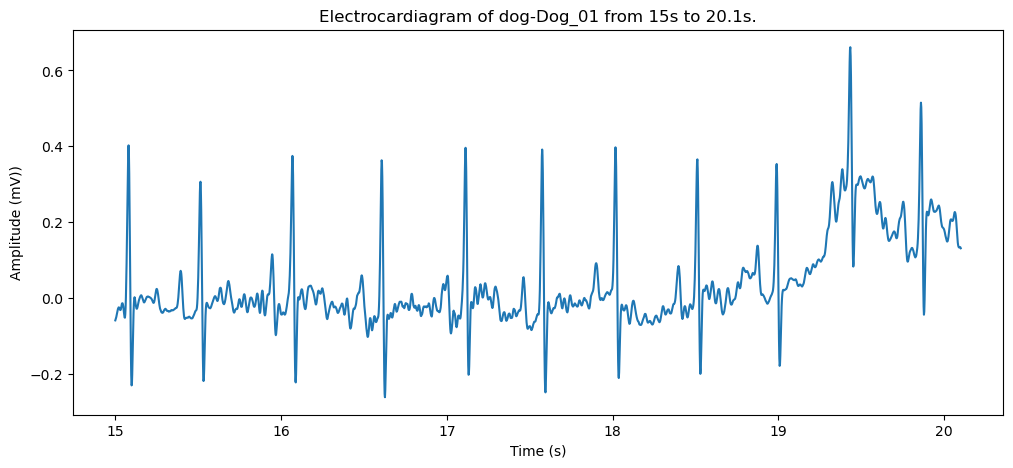

(array([15.        , 15.00200078, 15.00400157, ..., 20.09599843,
        20.09799922, 20.1       ]),
 array([-0.058889, -0.05614 , -0.053099, ...,  0.134288,  0.133684,
         0.131228]),
 5.1)

In [12]:
from scipy.signal import find_peaks
def plot_channel(mammal:str,name:str,start:float,duration:float):
    """
    Docstring generated by ChatGPT

    Plot a selected data channel for a given mammal over a specified time window.

    Parameters
    ----------
    mammal : str
        The name of the mammal.
    name : str
        The specific channel or recording name.
    start : float
        Start time in seconds for the segment to plot.
    duration : float
        Duration in seconds of the segment to plot.

    Description
    -----------
    This function retrieves the sampling frequency and signal data from the
    nested dictionary `d`, then plots the selected portion of the signal.
    If the requested duration extends beyond the available data, it is
    automatically adjusted to fit the valid range.

    Errors
    ------
    KeyError, NameError
        Raised if the provided `mammal` or `name` keys do not exist in `d`.
        In that case, available keys are printed to help the user correct the selection.

    Example
    -------
    >>> plot_channel(mammal='dog', name='Dog_01', start=0, duration=0.5)
 
    """
    #Test if the mammal and name are correct string for the code to work
    try:
        d[mammal][name]
    except (KeyError, NameError) as e:
        a = list(d.keys())
        b = {key: list(d[key].keys()) for key in a}
        print('An error has occurred, please check the selection:')
        print('Mammal keys:', a)
        print('Name keys  by mammal keys:', b)
        print('Error type:', type(e).__name__)
    
    #get the sample rate in the dictionarry d
    sample_rate=int(d[mammal][name]['Fs'])

    #get the number of measurements made on the subject
    len_data=len(d[mammal][name]['data'])

    #get the data of the given subject
    data=d[mammal][name]['data']

    #compute the duration of the electrocardiogram according to the number of measurement and the sample rate
    time_length=len_data/sample_rate

    #if start+duration exceed the time length 
    if start+duration>time_length:
        #we modify the duration to plor from the given start to the maximum time length
        duration=time_length - start

    #Convert the start time in a start index
    start_index=int(start*sample_rate)
    #Convert the duration time in a end index
    end_index=int((start+duration)*sample_rate)
    #Get the number of point between the start and the end
    number_points=end_index-start_index

    #Split between the start time and the end time into a number of points
    time_selection=np.linspace(start,start+duration,number_points)

    #create a subplot to set the size of the plot
    fig31, ax31 =plt.subplots(figsize=(12,5))

    #plot the data over a specified time window
    ax31.plot(time_selection,data[start_index:end_index])
    #set the title of the plot
    ax31.set_title(f"Electrocardiagram of {mammal}-{name} from {start}s to {start+duration}s.")
    #set the name of the x-label of the plot
    ax31.set_xlabel('Time (s)')
    #set the name of the y-label of the plot
    ax31.set_ylabel('Amplitude (mV))')
    #display the plot
    plt.show()
    #Returns some informations that will be useful for the next class
    return time_selection, data[start_index:end_index], duration

plot_channel(mammal='dog',name='Dog_01',start=15,duration=5.1)

### 3.2 Peak detection

1. Run a peak detection algorithm such as [`find_peaks`](https://docs.scipy.org/doc/scipy/reference/generated/scipy.signal.find_peaks.html) from `scipy.signal` to detect the local maxima (store these in an attribute of the object), which will give you the time/beat over that interval (time between two successive local maxima), which could easily be converted to beats/time = heart rate. Visualise the detected peaks by putting a star on the coordinates (time of local maximum, amplitude of local maximum) and add them to the plot function above.
1. visualise the heart rate as a function of time (choose the mid-point of the beat-to-beat interval as the reference time for the heart-rate computed over the beat-to-beat interval). The instant heart-rate may be considered as 1/(temporal distance separating two consecutive peaks).


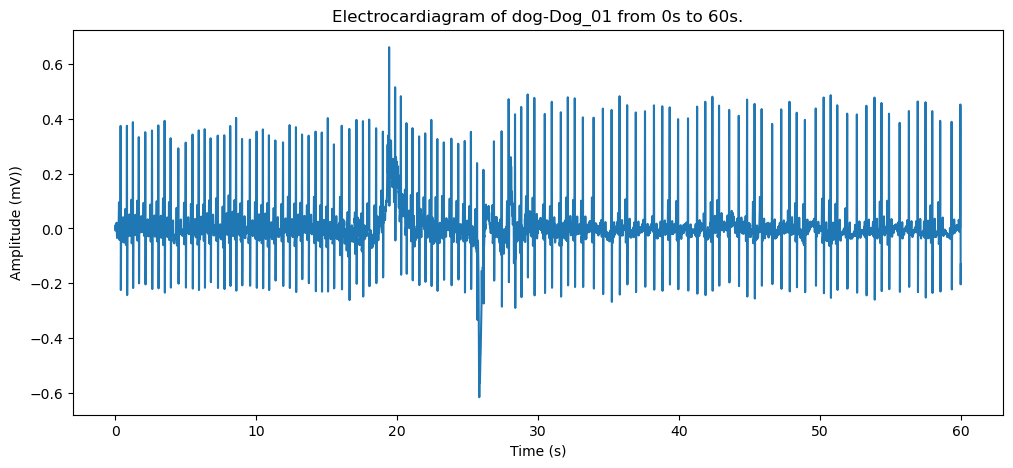

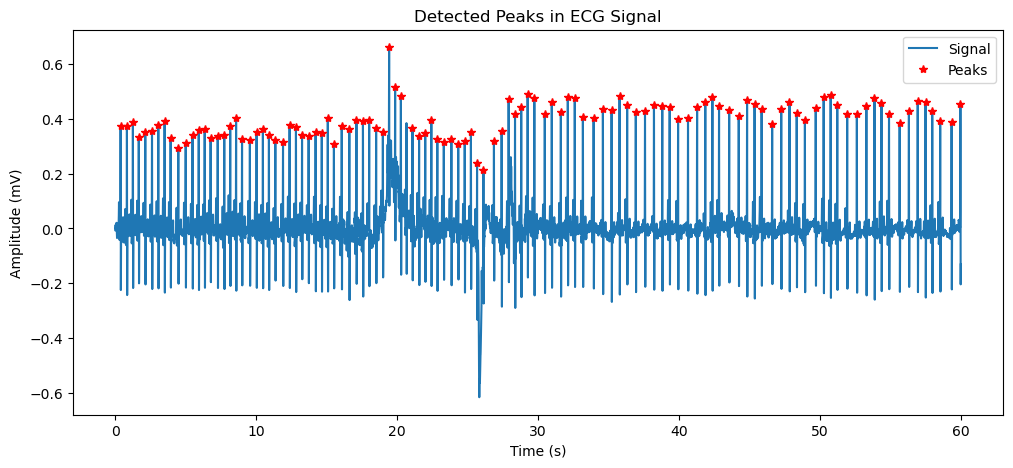

The heart rate of dog-Dog_01 is 113.00 per minute


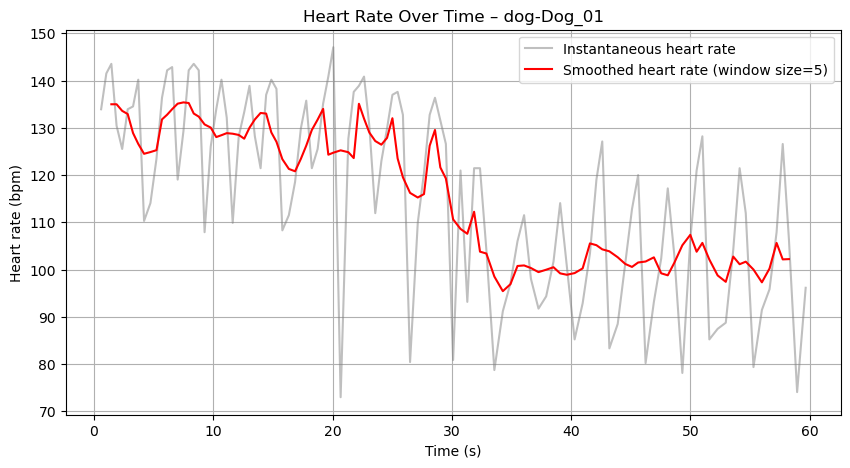

In [13]:
from scipy.signal import find_peaks
class electrocardiogram_analysis () :
    def __init__(self,mammal:str,name:str,start:float,duration:float, dist:int):
        """
        Initialize the variables into global variables
        Parameters
        ----------
        mammal : str
            The name of the mammal.
        name : str
            The specific channel or recording name.
        start : float
            Start time in seconds for the segment to plot.
        duration : float
            Duration in seconds of the segment to plot.
        dist: int
            Required minimal horizontal distance (>= 1) in samples between neighbouring peaks.
        """
        self.mammal, self.name, self.start, self.duration = mammal, name, start, duration
        self.time, self.data, self.duration= plot_channel(self.mammal, self.name, self.start, self.duration)
        #Find the peaks in the data
        self.peaks,self.properties=find_peaks(self.data, distance=dist)
        #Call plot_peaks() function
        self.plot_peaks()

    def plot_peaks(self):
        """
        Plot the peaks over the electrography, each peak corresponding to one heartbeat
        """
        #Get the values et each index where a peak occurs
        self.peak_values = self.data[self.peaks]
        #Set the size of the plot Frame
        plt.figure(figsize=(12, 5))
        #Plot the electrography
        plt.plot(self.time, self.data, label='Signal')
        #Plot the peaks over it
        plt.plot(self.time[self.peaks], self.peak_values, 'r*', label='Peaks')
        #Add labels to axis and title to the plot
        plt.xlabel('Time (s)')
        plt.ylabel('Amplitude (mV)')
        plt.title('Detected Peaks in ECG Signal')
        #Plot legend box
        plt.legend()
        plt.show()
        #Call heart_rate() function
        self.heart_rate()
    
    def heart_rate(self):
        """ 
        Take the number of peaks, divide it by the duration and multiply it by 60 to get the heart rate by minute
        """
        self.fheart=len(self.peaks)/(self.duration)*60
        #Print the heartbeat of the subject
        print(f'The heart rate of {self.mammal}-{self.name} is {self.fheart:.2f} per minute')
        #Call plot_heart_rate() function
        self.plot_heart_rate()

    def plot_heart_rate(self):
        """
        Plot the heart rate as of the function of time
        """
        #Initialize arrays to store midpoints between peaks 
        self.midpoint = np.zeros(len(self.peaks) - 1)
        #Initialize arrays to store midpoints between instantaneous heart rate
        self.instant_hb = np.zeros(len(self.peaks) - 1)

        #For each peak except the last one (to not be out of range)
        for k in range(len(self.peaks) - 1):
            #Calculate the midpoint between the peaks and the next one
            #Divided by the sample rate in order that the index is in second
            self.midpoint[k] = ((self.peaks[k] + self.peaks[k + 1]) / 2) / 500
            #Calculate the instantaneous heart rate per minute based on the time difference between the peak and the next one
            self.instant_hb[k] = 1 / (self.time[self.peaks[k + 1]] - self.time[self.peaks[k]]) * 60

        #We want to smooth the instanteanous heart rate over five points
        len_kernel = 5
        #Building the sliding kernel, that will slide over the signal
        kernel = np.ones(len_kernel) / len_kernel
        
        #https://stackoverflow.com/questions/78295801/numpy-convolve-with-valid
        #With 'valid' mode, the sliding kernel can't go out of the signal, that means the output will be smaller than the signal
        #of (len_kernel-1)/2 at the start and smaller of (len_kernel-1)/2 at the end
        #'same' mode, ensures that the resulting signal has the same number of values as the input signal. 
        #This implies, that we have to "make up" values to counter the effect of having fewer elements that we saw with mode="valid". 
        #As a consequence, in this mode, the signal is padded with zeros - before the convolution operation.
        smoothed_heart_rate = np.convolve(self.instant_hb, kernel, mode='valid')
        c=int((len_kernel-1)/2)
        #Create a new index with less value to display the smoothed heart rate
        self.newmidpoint=self.midpoint[c:-c]

        #Set the size of the plot Frame
        plt.figure(figsize=(10, 5))
        #Plot the instantaneous heart rate in gray
        plt.plot(self.midpoint, self.instant_hb, alpha=0.5, label='Instantaneous heart rate', color='gray')
        #Plot the smoothed heart rate in red
        plt.plot(self.newmidpoint, smoothed_heart_rate, label=f'Smoothed heart rate (window size={len_kernel})', color='red')
        #Add label to the axis and a title
        plt.xlabel('Time (s)')
        plt.ylabel('Heart rate (bpm)')
        plt.title(f'Heart Rate Over Time – {self.mammal}-{self.name}')
        #Add a box legend
        plt.legend()
        #Add grid to the plot
        plt.grid(True)
        plt.show()


electrocardiogram_analysis(mammal='dog',name='Dog_01',start=0,duration=60, dist=200)